# Trajectory → hex aggregation → choropleth

This notebook demonstrates the complete pipeline from raw positional data to a choropleth map:

1. Set up a `HexProj` instance covering the North Sea.
2. Generate synthetic trajectory positions scattered over the region.
3. Assign a hex ID to every position with `hp.label()`.
4. Count visits per hex with a pandas `value_counts()`.
5. Build the full hex universe for the region polygon.
6. Join counts onto that universe so unvisited hexes show zero.
7. Plot the result as a choropleth with a coastline overlay.

## Imports

In [1]:
from hextraj import HexProj

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib import pyplot as plt

## Projection setup

We use Lambert Azimuthal Equal-Area centred on the North Sea (10 °E, 55 °N) with 20 km hexes — fine enough to resolve individual shipping lanes.

In [2]:
hp = HexProj(
    projection_name="laea",
    lon_origin=10,
    lat_origin=55,
    hex_size_meters=20_000,
)
hp

HexProj(projection_name='laea', lon_origin=10, lat_origin=55, hex_size_meters=20000, hex_orientation='flat', )

## Synthetic ship tracks

We generate 10 synthetic vessel trajectories that follow realistic North Sea routes — Dover Strait to the Norwegian coast, Rotterdam to Aberdeen, English Channel to Skagerrak, and similar corridors. Each track is a straight-line great-circle route between two waypoints with small random-walk noise added at every step (std ≈ 0.05–0.1 °) to mimic realistic GPS traces. All tracks are concatenated into a single lon/lat array.

When aggregated onto the hex grid, this produces high visit counts along the main shipping lanes and near-zero counts elsewhere — much closer to real AIS density patterns than a Gaussian blob.

In [3]:
rng = np.random.default_rng(seed=42)

In [4]:
# Realistic North Sea routes: (lon_start, lat_start, lon_end, lat_end, n_steps, noise_std)
routes = [
    ( 2.0, 51.1,  5.0, 58.0, 400, 0.06),   # Dover Strait → Norwegian coast
    ( 4.2, 51.9, -2.1, 57.1, 350, 0.07),   # Rotterdam → Aberdeen
    ( 1.5, 51.0,  9.8, 57.5, 450, 0.08),   # English Channel → Skagerrak
    ( 5.3, 53.1,  8.7, 58.3, 300, 0.05),   # IJmuiden → Bergen
    ( 0.1, 51.4,  4.9, 57.9, 380, 0.07),   # Thames estuary → Stavanger
    (-1.6, 57.2,  5.5, 58.6, 250, 0.06),   # Aberdeen → Stavanger
    ( 7.0, 53.3, 10.5, 57.8, 320, 0.05),   # Bremerhaven → Göteborg
    ( 4.5, 52.0,  8.8, 58.2, 360, 0.08),   # Rotterdam → Bergen
    ( 1.8, 51.2,  8.1, 55.5, 280, 0.06),   # Dover → Danish coast
    ( 3.0, 53.0, 10.0, 58.5, 420, 0.09),   # North Sea crossing (central)
]

In [5]:
track_lons, track_lats = [], []

for lon0, lat0, lon1, lat1, n, noise_std in routes:
    t = np.linspace(0, 1, n)
    lons = lon0 + (lon1 - lon0) * t + rng.normal(0, noise_std, size=n).cumsum() * 0.1
    lats = lat0 + (lat1 - lat0) * t + rng.normal(0, noise_std, size=n).cumsum() * 0.1
    track_lons.append(lons)
    track_lats.append(lats)

In [6]:
lon = np.concatenate(track_lons)
lat = np.concatenate(track_lats)
print(f"{len(lon):,} positions across {len(routes)} ship tracks")

3,510 positions across 10 ship tracks


## Label positions

`hp.label()` maps every (lon, lat) pair to a single `int64` hex ID.

In [7]:
hex_ids = hp.label(lon, lat)
print(f"Unique hexes visited: {len(np.unique(hex_ids))}")

Unique hexes visited: 196


## Aggregate — count visits per hex

`pd.Series.value_counts()` gives us the number of positions that fell inside each hex ID.

In [8]:
counts = pd.Series(hex_ids).value_counts()
counts.head()

667    50
286    49
284    48
288    48
339    48
Name: count, dtype: int64

## Build the full hex universe for the region

We use the same rough North Sea polygon as in `hex_grid_construction.ipynb`. `region_of_hexes` returns every hex whose polygon intersects the region; `to_geodataframe` converts those IDs to a GeoDataFrame with hex polygons in EPSG:4326.

The synthetic tracks only pass through a subset of hexes — including the full regional universe means route-free hexes appear in the lightest colour rather than being absent from the map.

In [9]:
north_sea = Polygon([
    (-5,  57),
    ( 2,  51),
    ( 9,  53),
    (12,  56),
    ( 8,  58),
    ( 5,  62),
    (-3,  60),
    (-5,  57),
])

In [10]:
region_gdf = hp.to_geodataframe(hp.region_of_hexes(north_sea))
print(f"{len(region_gdf)} hexes in North Sea region")
region_gdf.head()

772 hexes in North Sea region


,geometry
5611,"POLYGON ((-4.46675 56.66501, -4.56734 56.49466..."
5826,"POLYGON ((-4.58574 56.96852, -4.68643 56.79807..."
6045,"POLYGON ((-4.70701 57.27188, -4.80778 57.10134..."
4793,"POLYGON ((-3.70733 55.9591, -3.80979 55.78933,..."
4992,"POLYGON ((-3.81737 56.26343, -3.91998 56.09358..."


## Join counts onto the hex universe

We reindex the visit counts against the full set of regional hex IDs and fill missing values with zero. This left-join pattern ensures that hexes with no visits appear as 0 rather than NaN, which keeps the colour scale honest.

In [11]:
region_gdf["count"] = counts.reindex(region_gdf.index).fillna(0).astype(int)
region_gdf[["count"]].describe()

,count
count,772.000000
mean,4.338083
std,9.258274
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,50.000000


## Plot choropleth

Each hex is coloured by its visit count using a sequential colour map (yellow → red). Coastlines from Natural Earth (same URL as in `hex_grid_construction.ipynb`) are overlaid for geographic context. Hexes with zero visits appear in the lightest yellow, making the density gradient immediately legible.

In [12]:
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

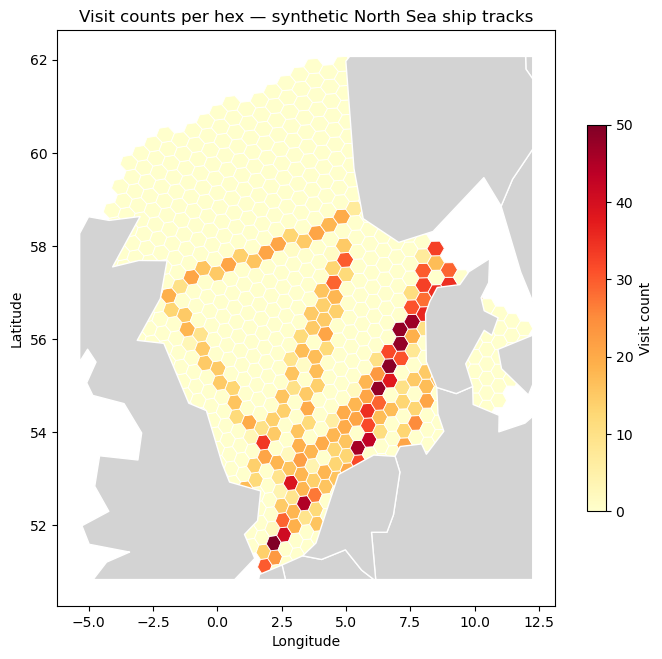

In [13]:
ax = region_gdf.plot(
    column="count",
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.6,
    figsize=(7, 7),
    legend=True,
    legend_kwds={"label": "Visit count", "shrink": 0.6},
)
world.clip(region_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white")
ax.set_title("Visit counts per hex — synthetic North Sea ship tracks")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()